In [3]:
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report
import transformers
from transformers import AutoModel, BertTokenizerFast
# import polars as pd

# specify GPU
device = torch.device("mps")

In [4]:
rna_prot = pd.read_excel(
    "data/1-s2.0-S2666379124002398-mmc3.xlsx",
    sheet_name="Abundance_gene_MD_protein",
    engine="calamine",
)
metabolomics = pd.read_excel(
    "data/1-s2.0-S2666379124002398-mmc9.xlsx",
    sheet_name="compound_abundance",
    engine="calamine",
)

rna_prot = rna_prot.drop(
    columns=[
        col
        for col in rna_prot.columns
        if not col.endswith("T") and not col.endswith("N")
    ]
)
rna_prot = rna_prot.fillna(rna_prot.median())

metabolomics = metabolomics.drop(columns="Name")
metabolomics = metabolomics.fillna(metabolomics.median())

In [5]:
# t stands for tumor, n for control
data_list = []

for col in metabolomics.columns:
    label = 1 if col.startswith("T") else 0
    data_list.append(
        {
            "omic_elem": metabolomics[col].values,  # This stores the whole array
            "label": label,
        }
    )

new_metab = pd.DataFrame(data_list)

In [6]:
data_list = []

for col in rna_prot.columns:
    label = 1 if col.endswith("T") else 0
    data_list.append(
        {
            "omic_elem": rna_prot[col].values,  # This stores the whole array
            "label": label,
        }
    )

new_rna = pd.DataFrame(data_list)

In [7]:
print(metabolomics.head())
print(rna_prot.head())

   C3L-02204-T  C3L-02212-T  C3L-02210-T  C3L-01469-T  C3L-01467-T  \
0    20.533573    21.889116    22.318547    20.832142    18.972544   
1    25.055998    23.124522    21.916710    24.774021    25.170298   
2    26.944278    24.638104    23.438863    26.654735    26.940019   
3    23.152135    20.106905    20.189361    24.488558    21.761984   
4    23.653580    21.038361    20.334594    22.232766    23.154931   

   C3L-01458-T  C3L-01460-T  C3L-00608-T  C3L-01865-T  C3L-01865-N  ...  \
0    19.896306    24.223183    20.723298    18.652031    18.093279  ...   
1    23.623984    23.137100    23.911895    24.284740    23.530207  ...   
2    25.162153    24.912303    26.123601    26.430455    25.679523  ...   
3    23.213142    22.285372    21.426636    20.425519    21.056830  ...   
4    23.027073    21.232895    20.779034    22.528226    22.534392  ...   

   C3L-01960-T  C3L-01953-T  C3L-01463-T  C3L-01461-T  C3N-00438-T  \
0    23.066619    23.901579    22.483670    17.857268    1

In [8]:
# shuffle rows
new_metab = new_metab.sample(frac=1).reset_index(drop=True)
new_rna = new_rna.sample(frac=1).reset_index(drop=True)

In [9]:
# get bert
bert = AutoModel.from_pretrained("bert-base-uncased")

# Load the BERT tokenizer
tokenizer = BertTokenizerFast.from_pretrained("bert-base-uncased")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: bert-base-uncased
Key                                        | Status     |  | 
-------------------------------------------+------------+--+-
cls.seq_relationship.weight                | UNEXPECTED |  | 
cls.predictions.bias                       | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED |  | 
cls.predictions.transform.dense.weight     | UNEXPECTED |  | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED |  | 
cls.predictions.transform.dense.bias       | UNEXPECTED |  | 
cls.seq_relationship.bias                  | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


In [10]:
# split train dataset into train, validation and test sets
train_text, temp_text, train_labels, temp_labels = train_test_split(
    new_rna["omic_elem"],
    new_rna["label"],
    random_state=42,  # ;)
    test_size=0.3,
    stratify=new_rna["label"],
)


val_text, test_text, val_labels, test_labels = train_test_split(
    temp_text, temp_labels, random_state=42, test_size=0.5, stratify=temp_labels
)

<Axes: >

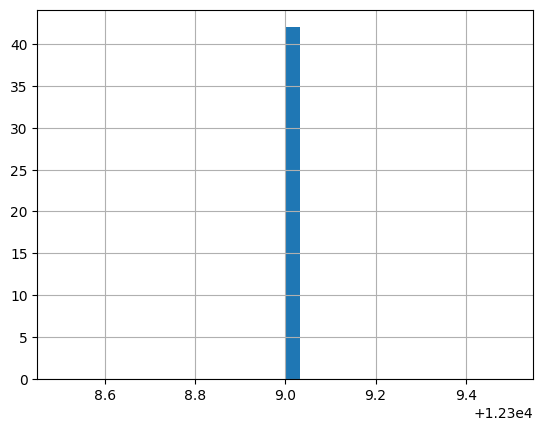

In [11]:
# get length of all the messages in the train set
seq_len = [len(i) for i in train_text]
pd.Series(seq_len).hist(bins=30)

In [12]:
tokens_train = tokenizer(
    train_text.astype(
        str
    ).tolist(),  # we're interpreting numbers as strings - mmmmmh fishy
    max_length=25,
    truncation=True,
)

# tokenize and encode sequences in the validation set
tokens_val = tokenizer(val_text.astype(str).tolist(), max_length=25, truncation=True)

# tokenize and encode sequences in the test set
tokens_test = tokenizer(test_text.astype(str).tolist(), max_length=25, truncation=True)

In [13]:
train_seq = torch.tensor(tokens_train["input_ids"])
train_mask = torch.tensor(tokens_train["attention_mask"])
train_y = torch.tensor(train_labels.tolist())

val_seq = torch.tensor(tokens_val["input_ids"])
val_mask = torch.tensor(tokens_val["attention_mask"])
val_y = torch.tensor(val_labels.tolist())

test_seq = torch.tensor(tokens_test["input_ids"])
test_mask = torch.tensor(tokens_test["attention_mask"])
test_y = torch.tensor(test_labels.tolist())

In [14]:
from torch.utils.data import TensorDataset, DataLoader, RandomSampler, SequentialSampler

# define a batch size
batch_size = 32

# wrap tensors
train_data = TensorDataset(train_seq, train_mask, train_y)

# sampler for sampling the data during training
train_sampler = RandomSampler(train_data)

# dataLoader for train set
train_dataloader = DataLoader(train_data, sampler=train_sampler, batch_size=batch_size)

# wrap tensors
val_data = TensorDataset(val_seq, val_mask, val_y)

# sampler for sampling the data during training
val_sampler = SequentialSampler(val_data)

# dataLoader for validation set
val_dataloader = DataLoader(val_data, sampler=val_sampler, batch_size=batch_size)

In [15]:
# (don't) freeze all the parameters
for param in bert.parameters():
    param.requires_grad = True

In [16]:
class BERT_Arch(nn.Module):
    def __init__(self, bert):
        super(BERT_Arch, self).__init__()

        self.bert = bert

        # dropout layer
        self.dropout = nn.Dropout(0.1)

        # relu activation function
        self.relu = nn.ReLU()

        # dense layer 1
        self.fc1 = nn.Linear(768, 512)

        # dense layer 2 (Output layer)
        self.fc2 = nn.Linear(512, 2)

        # softmax activation function
        self.softmax = nn.LogSoftmax(dim=1)

    # define the forward pass
    def forward(self, sent_id, mask):

        # pass the inputs to the model
        _, cls_hs = self.bert(sent_id, attention_mask=mask, return_dict=False)

        x = self.fc1(cls_hs)

        x = self.relu(x)

        x = self.dropout(x)

        # output layer
        x = self.fc2(x)

        # apply softmax activation
        x = self.softmax(x)

        return x

In [17]:
# pass the pre-trained BERT to our define architecture
model = BERT_Arch(bert)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
# push the model to GPU
model = model.to(device)

In [18]:
# optimizer from hugging face transformers
from torch.optim import AdamW

# define the optimizer
optimizer = AdamW(model.parameters(), lr=1e-5)

In [19]:
from sklearn.utils.class_weight import compute_class_weight

# compute the class weights
class_weights = compute_class_weight(
    class_weight="balanced", classes=np.unique(train_labels), y=train_labels
)
print("Class Weights:", class_weights)

Class Weights: [1.61538462 0.72413793]


In [20]:
# converting list of class weights to a tensor
weights = torch.tensor(class_weights, dtype=torch.float)

# push to GPU
weights = weights.to(device)

# define the loss function
cross_entropy = nn.NLLLoss(weight=weights)

# number of training epochs
epochs = 100

In [21]:
# function to train the model
def train():

    model.train()
    total_loss, total_accuracy = 0, 0

    # empty list to save model predictions
    total_preds = []

    # iterate over batches
    for step, batch in enumerate(train_dataloader):
        # progress update after every 50 batches.
        if step % 50 == 0 and not step == 0:
            print("  Batch {:>5,}  of  {:>5,}.".format(step, len(train_dataloader)))

        # push the batch to gpu
        batch = [r.to(device) for r in batch]

        sent_id, mask, labels = batch

        # clear previously calculated gradients
        model.zero_grad()

        # get model predictions for the current batch
        preds = model(sent_id, mask)

        # compute the loss between actual and predicted values
        loss = cross_entropy(preds, labels)

        # add on to the total loss
        total_loss = total_loss + loss.item()

        # backward pass to calculate the gradients
        loss.backward()

        # clip the the gradients to 1.0. It helps in preventing the exploding gradient problem
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)

        # update parameters
        optimizer.step()

        # model predictions are stored on GPU. So, push it to CPU
        preds = preds.detach().cpu().numpy()

    # append the model predictions
    total_preds.append(preds)

    # compute the training loss of the epoch
    avg_loss = total_loss / len(train_dataloader)

    # predictions are in the form of (no. of batches, size of batch, no. of classes).
    # reshape the predictions in form of (number of samples, no. of classes)
    total_preds = np.concatenate(total_preds, axis=0)
    # returns the loss and predictions
    return avg_loss, total_preds

In [22]:
import time


# function for evaluating the model
def evaluate():

    print("\nEvaluating...")
    t0 = time.time()
    # deactivate dropout layers
    model.eval()

    total_loss, total_accuracy = 0, 0

    # empty list to save the model predictions
    total_preds = []

    # iterate over batches
    for step, batch in enumerate(val_dataloader):
        # Progress update every 50 batches.
        if step % 50 == 0 and not step == 0:
            # Calculate elapsed time in minutes.
            elapsed = time.time() - t0

            # Report progress.
            print("  Batch {:>5,}  of  {:>5,}.".format(step, len(val_dataloader)))

        # push the batch to gpu
        batch = [t.to(device) for t in batch]

        sent_id, mask, labels = batch

        # deactivate autograd
        with torch.no_grad():
            # model predictions
            preds = model(sent_id, mask)

            # compute the validation loss between actual and predicted values
            loss = cross_entropy(preds, labels)

            total_loss = total_loss + loss.item()

            preds = preds.detach().cpu().numpy()

            total_preds.append(preds)

    # compute the validation loss of the epoch
    avg_loss = total_loss / len(val_dataloader)

    # reshape the predictions in form of (number of samples, no. of classes)
    total_preds = np.concatenate(total_preds, axis=0)

    return avg_loss, total_preds

In [23]:
# set initial loss to infinite
best_valid_loss = float("inf")

# empty lists to store training and validation loss of each epoch
train_losses = []
valid_losses = []

# for each epoch
for epoch in range(epochs):
    print("\n Epoch {:} / {:}".format(epoch + 1, epochs))

    # train model
    train_loss, _ = train()

    # evaluate model
    valid_loss, _ = evaluate()

    # save the best model
    if valid_loss < best_valid_loss:
        best_valid_loss = valid_loss
        torch.save(model.state_dict(), "saved_weights.pt")

    # append training and validation loss
    train_losses.append(train_loss)
    valid_losses.append(valid_loss)

    print(f"\nTraining Loss: {train_loss:.3f}")
    print(f"Validation Loss: {valid_loss:.3f}")


 Epoch 1 / 100

Evaluating...

Training Loss: 0.706
Validation Loss: 0.701

 Epoch 2 / 100

Evaluating...

Training Loss: 0.695
Validation Loss: 0.694

 Epoch 3 / 100

Evaluating...

Training Loss: 0.690
Validation Loss: 0.693

 Epoch 4 / 100

Evaluating...

Training Loss: 0.678
Validation Loss: 0.697

 Epoch 5 / 100

Evaluating...

Training Loss: 0.694
Validation Loss: 0.688

 Epoch 6 / 100

Evaluating...

Training Loss: 0.687
Validation Loss: 0.696

 Epoch 7 / 100

Evaluating...

Training Loss: 0.691
Validation Loss: 0.703

 Epoch 8 / 100

Evaluating...

Training Loss: 0.672
Validation Loss: 0.711

 Epoch 9 / 100

Evaluating...

Training Loss: 0.646
Validation Loss: 0.715

 Epoch 10 / 100

Evaluating...

Training Loss: 0.673
Validation Loss: 0.699

 Epoch 11 / 100

Evaluating...

Training Loss: 0.653
Validation Loss: 0.675

 Epoch 12 / 100

Evaluating...

Training Loss: 0.615
Validation Loss: 0.661

 Epoch 13 / 100

Evaluating...

Training Loss: 0.601
Validation Loss: 0.653

 Epoch 

In [24]:
# load weights of best model
path = "saved_weights.pt"
model.load_state_dict(torch.load(path))

<All keys matched successfully>

In [25]:
# get predictions for test data
with torch.no_grad():
    preds = model(test_seq.to(device), test_mask.to(device))
    preds = preds.detach().cpu().numpy()

In [26]:
# model's performance
preds = np.argmax(preds, axis=1)
print(classification_report(test_y, preds))

              precision    recall  f1-score   support

           0       0.25      0.33      0.29         3
           1       0.60      0.50      0.55         6

    accuracy                           0.44         9
   macro avg       0.42      0.42      0.42         9
weighted avg       0.48      0.44      0.46         9



## ignora


In [103]:
import torch
import torch.nn as nn
import torch.nn.functional as F


class OmicsBERT(nn.Module):
    def __init__(self, num_genes, d_model=256, nhead=8, layers=4):
        super().__init__()
        self.gene_embed = nn.Embedding(num_genes, d_model)

        # expression projection
        self.expr_proj = nn.Linear(1, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=nhead, dim_feedforward=1024, batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, layers)

        # reconstruction head
        self.head = nn.Sequential(
            nn.Linear(d_model, d_model), nn.ReLU(), nn.Linear(d_model, 1)
        )

    def forward(self, gene_ids, expr_values):
        gene_emb = self.gene_embed(gene_ids)
        expr_emb = self.expr_proj(expr_values.unsqueeze(-1))
        x = gene_emb + expr_emb
        z = self.encoder(x)
        pred_expr = self.head(z).squeeze(-1)

        return pred_expr

In [104]:
def mask_inputs(expr, mask_ratio=0.15):

    mask = torch.rand(expr.shape) < mask_ratio
    masked_expr = expr.clone()
    masked_expr[mask] = 0

    return masked_expr, mask

In [105]:
model = OmicsBERT(num_genes=5000)
opt = torch.optim.Adam(model.parameters(), lr=1e-4)
dataloader = ...  # boh
for gene_ids, expr in dataloader:
    masked_expr, mask = mask_inputs(expr)

    pred = model(gene_ids, masked_expr)

    loss = F.mse_loss(pred[mask], expr[mask])

    opt.zero_grad()
    loss.backward()
    opt.step()

TypeError: 'ellipsis' object is not iterable

### ignora

In [ ]:
class MultiOmicsBERT(nn.Module):
    def __init__(self, num_features, num_modalities, d_model=256):

        super().__init__()

        self.feature_embed = nn.Embedding(num_features, d_model)

        self.mod_embed = nn.Embedding(num_modalities, d_model)

        self.value_proj = nn.Linear(1, d_model)

        encoder_layer = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=8, batch_first=True
        )

        self.encoder = nn.TransformerEncoder(encoder_layer, 4)

        self.head = nn.Linear(d_model, 1)

    def forward(self, feature_ids, modality_ids, values):

        f = self.feature_embed(feature_ids)

        m = self.mod_embed(modality_ids)

        v = self.value_proj(values.unsqueeze(-1))

        x = f + m + v

        z = self.encoder(x)

        pred = self.head(z).squeeze(-1)

        return pred